# Business Analytics Case Study: Early Prediction of At-Risk Students
**Dataset:** 10,038 Total Records (38 Primary Survey Responses + 10,000 Web-Scraped Records)  
**Models:** Decision Tree Classifier, Random Forest, Logistic Regression


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load Primary Survey (38 responses) and Master Cleaned Dataset (10,038 records)
df_survey = pd.read_csv('data/survey_38_raw.csv')
df_clean = pd.read_csv('data/cleaned_dataset.csv')

print(f"Primary Survey Shape: {df_survey.shape}")
print(f"Master Cleaned Dataset Shape: {df_clean.shape}")

# Display First 5 Rows of Cleaned Dataset
df_clean.head()

Primary Survey Shape: (38, 23)
Master Cleaned Dataset Shape: (10038, 32)


,Student_ID,Q1_Age_Group,Q2_Year_of_Study,Q3_Field_of_Study,Q4_Platform,Q5_Course_Type,Q6_Course_Duration,Q7_Daily_Study_Time,Q8_Weekly_Study_Days,Q9_Study_Schedule_Regularity,...,Q22_Future_Course_Likelihood,Daily_Study_Hours,Weekly_Study_Days_Num,Assignment_Completion_Score,Video_Watching_Score,Forum_Participation_Score,Break_Frequency_Score,Course_Difficulty_Score,Internet_Quality_Score,Target_Completed
0,SURVEY_101,Above 26,3rd Year,Engineering,Coursera,Programming / Technology,Less than 2 weeks,2–3 hours,4–5 days,4,...,Probably Yes,2.50,4.5,5,5,1,2,2,3,1
1,SURVEY_102,18–20,2nd Year,Engineering,edX,Programming / Technology,1–3 months,1–2 hours,1 day,4,...,Probably Yes,1.50,1.0,2,5,0,4,3,4,1
2,SURVEY_103,24–26,2nd Year,Engineering,Coursera,Artificial Intelligence / Data Science,1–3 months,Less than 30 minutes,Every day,4,...,Not Sure,0.25,7.0,5,4,0,1,2,3,1
3,SURVEY_104,18–20,3rd Year,Computer Science / IT,edX,Programming / Technology,More than 6 months,1–2 hours,2–3 days,1,...,Definitely Yes,1.50,2.5,4,4,4,1,3,4,1
4,SURVEY_105,18–20,3rd Year,Engineering,YouTube,Artificial Intelligence / Data Science,2–4 weeks,1–2 hours,4–5 days,3,...,Probably No,1.50,4.5,4,4,2,1,2,4,1


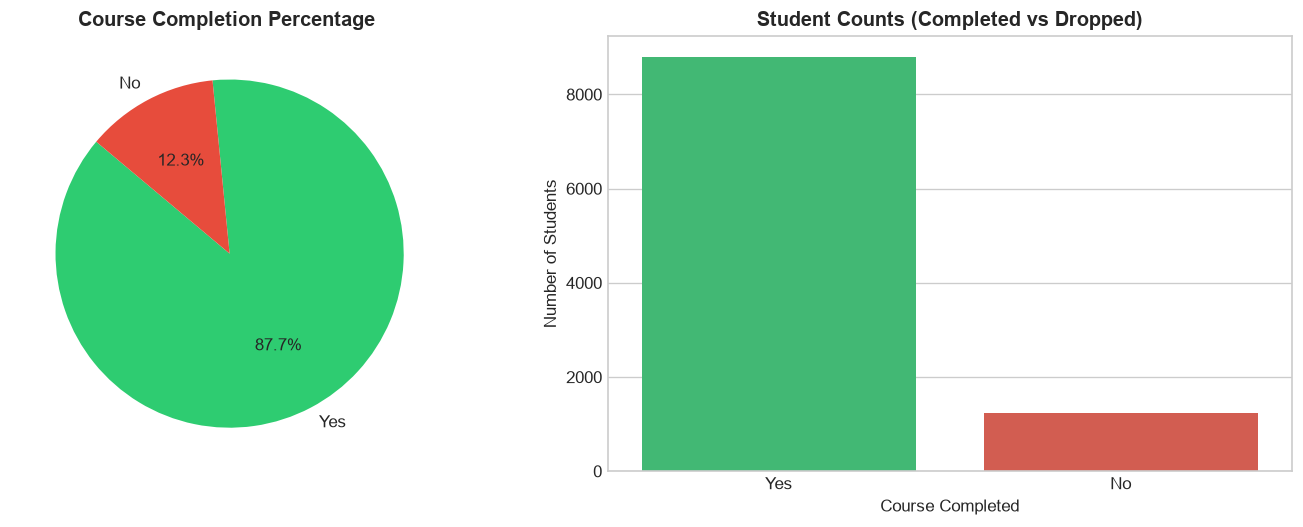

In [3]:
# 1. Target Variable Distribution (Course Completion Rate)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

counts = df_clean['Q19_Course_Completed'].value_counts()
ax[0].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=['#2ecc71', '#e74c3c'])
ax[0].set_title('Course Completion Percentage ', fontweight='bold')

sns.countplot(data=df_clean, x='Q19_Course_Completed', palette=['#2ecc71', '#e74c3c'], ax=ax[1])
ax[1].set_title('Student Counts (Completed vs Dropped)', fontweight='bold')
ax[1].set_xlabel('Course Completed')
ax[1].set_ylabel('Number of Students')

plt.tight_layout()
plt.show()

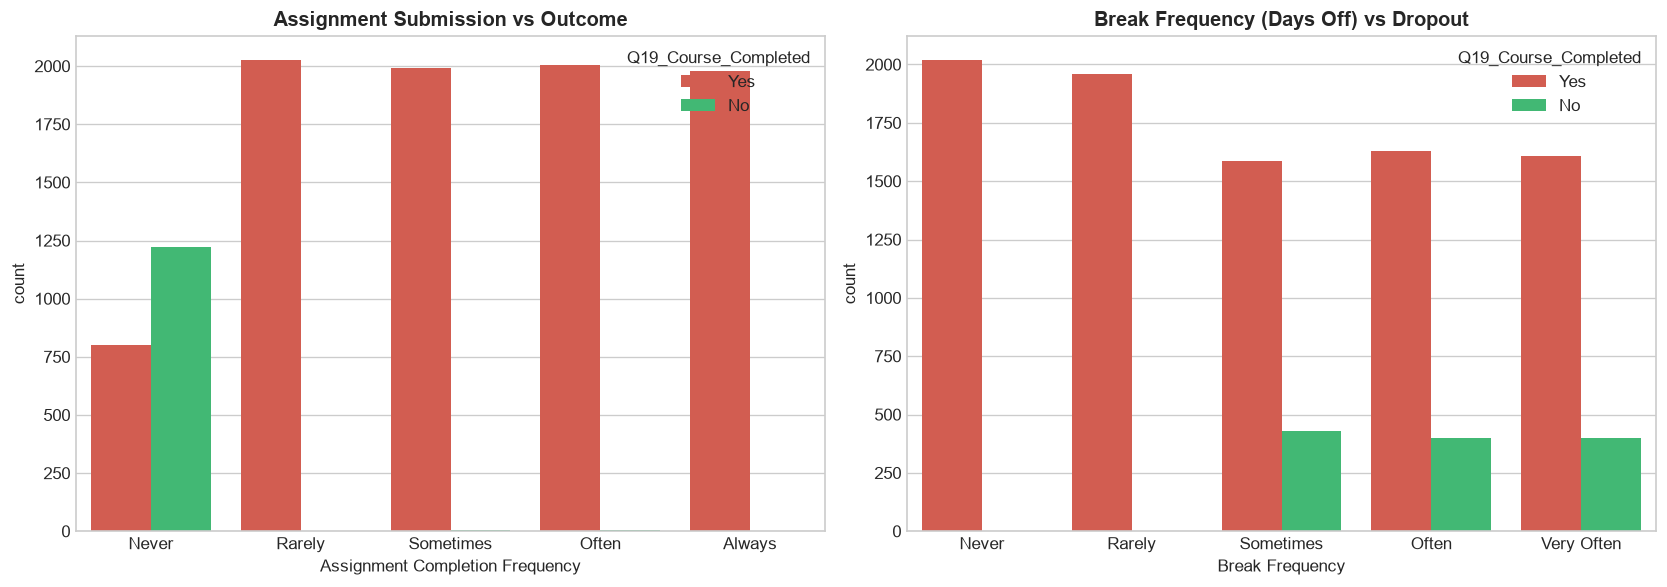

In [4]:
# 2. Behavioral Engagement: Assignments & Break Frequency vs Completion
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x='Q11_Assignment_Completion', hue='Q19_Course_Completed',
              order=['Never', 'Rarely', 'Sometimes', 'Often', 'Always'],
              palette=['#e74c3c', '#2ecc71'], ax=ax[0])
ax[0].set_title('Assignment Submission vs Outcome', fontweight='bold')
ax[0].set_xlabel('Assignment Completion Frequency')

sns.countplot(data=df_clean, x='Q14_Break_Frequency', hue='Q19_Course_Completed',
              order=['Never', 'Rarely', 'Sometimes', 'Often', 'Very Often'],
              palette=['#e74c3c', '#2ecc71'], ax=ax[1])
ax[1].set_title('Break Frequency (Days Off) vs Dropout', fontweight='bold')
ax[1].set_xlabel('Break Frequency')

plt.tight_layout()
plt.show()

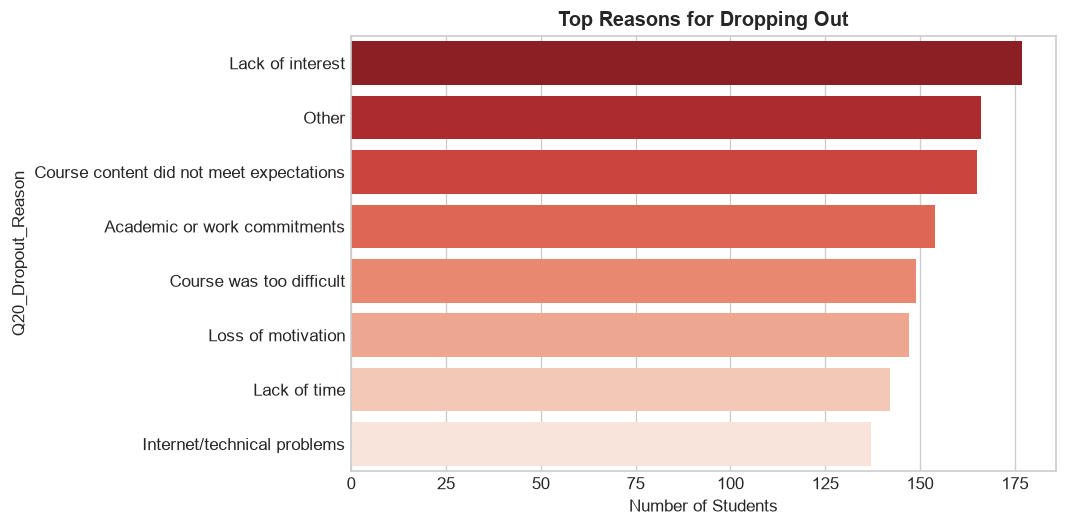

In [5]:
# 3. Main Reasons for Non-Completion (Dropped Students)
plt.figure(figsize=(9, 4.5))
drop_df = df_clean[df_clean['Q19_Course_Completed'] == 'No']
reason_counts = drop_df['Q20_Dropout_Reason'].value_counts()

sns.barplot(x=reason_counts.values, y=reason_counts.index, palette='Reds_r')
plt.title('Top Reasons for Dropping Out', fontweight='bold')
plt.xlabel('Number of Students')
plt.tight_layout()
plt.show()

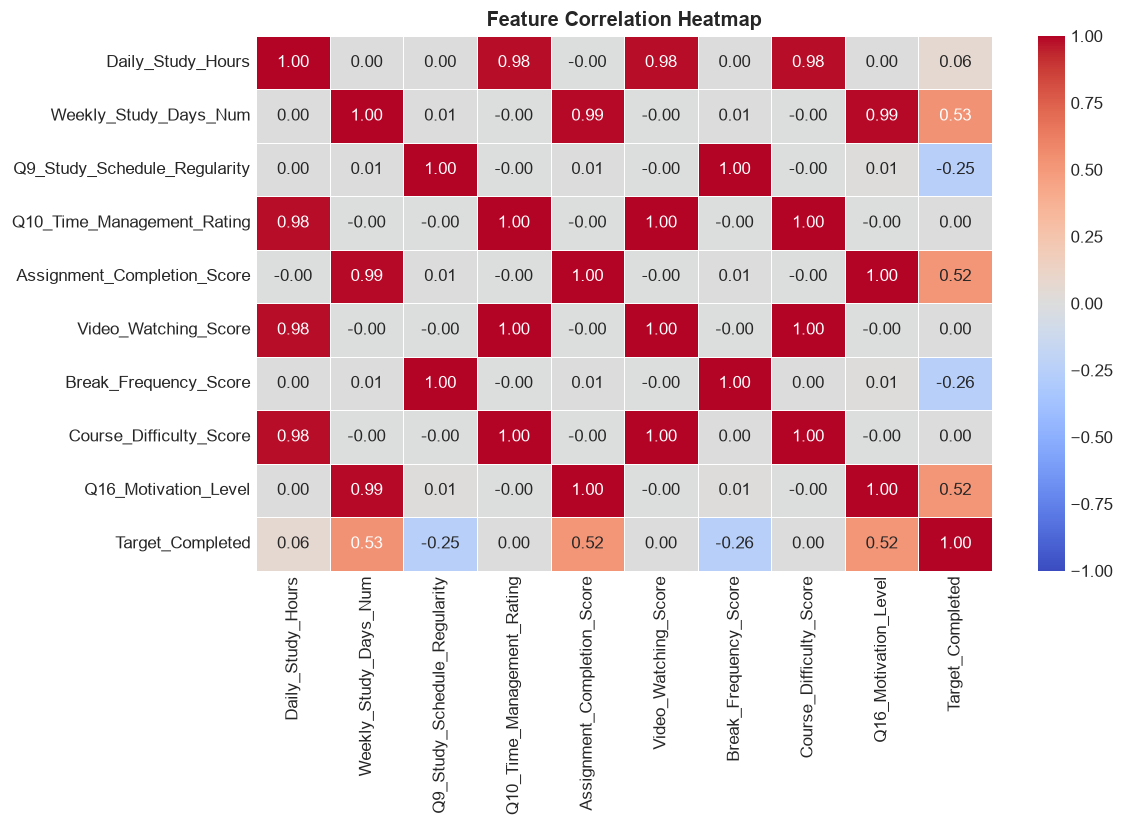

In [6]:
# 4. Feature Correlation Matrix
num_cols = ['Daily_Study_Hours', 'Weekly_Study_Days_Num', 'Q9_Study_Schedule_Regularity', 
            'Q10_Time_Management_Rating', 'Assignment_Completion_Score', 'Video_Watching_Score', 
            'Break_Frequency_Score', 'Course_Difficulty_Score', 'Q16_Motivation_Level', 'Target_Completed']

plt.figure(figsize=(10, 7))
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Define Features & Target Variable
feature_cols = [
    'Daily_Study_Hours', 'Weekly_Study_Days_Num', 'Q9_Study_Schedule_Regularity',
    'Q10_Time_Management_Rating', 'Assignment_Completion_Score', 'Video_Watching_Score',
    'Break_Frequency_Score', 'Course_Difficulty_Score', 'Q16_Motivation_Level'
]

X = df_clean[feature_cols]
y = df_clean['Target_Completed']

# 75/25 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Training Samples: {X_train.shape[0]}, Test Samples: {X_test.shape[0]}")

Training Samples: 7528, Test Samples: 2510


In [8]:
# Train Models
dt_model = DecisionTreeClassifier(max_depth=3, min_samples_split=3, random_state=42)
rf_model = RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

models = {'Decision Tree': dt_model, 'Random Forest': rf_model, 'Logistic Regression': lr_model}
eval_results = []

for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    eval_results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1-Score': round(f1_score(y_test, preds), 4),
        'ROC-AUC': round(roc_auc_score(y_test, probs), 4)
    })

df_metrics = pd.DataFrame(eval_results)
print("=== Model Performance Comparison ===")
df_metrics

=== Model Performance Comparison ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.9984,0.9982,1.0000,0.9991,0.9941
1,Random Forest,0.9980,0.9982,0.9995,0.9989,0.9988
2,Logistic Regression,0.9980,0.9986,0.9991,0.9989,0.9961


=== Decision Tree Rules ===
|--- Assignment_Completion_Score <= 1.50
|   |--- Break_Frequency_Score <= 2.50
|   |   |--- class: 1
|   |--- Break_Frequency_Score >  2.50
|   |   |--- class: 0
|--- Assignment_Completion_Score >  1.50
|   |--- Q16_Motivation_Level <= 1.50
|   |   |--- Video_Watching_Score <= 3.50
|   |   |   |--- class: 0
|   |   |--- Video_Watching_Score >  3.50
|   |   |   |--- class: 1
|   |--- Q16_Motivation_Level >  1.50
|   |   |--- Weekly_Study_Days_Num <= 1.75
|   |   |   |--- class: 1
|   |   |--- Weekly_Study_Days_Num >  1.75
|   |   |   |--- class: 1



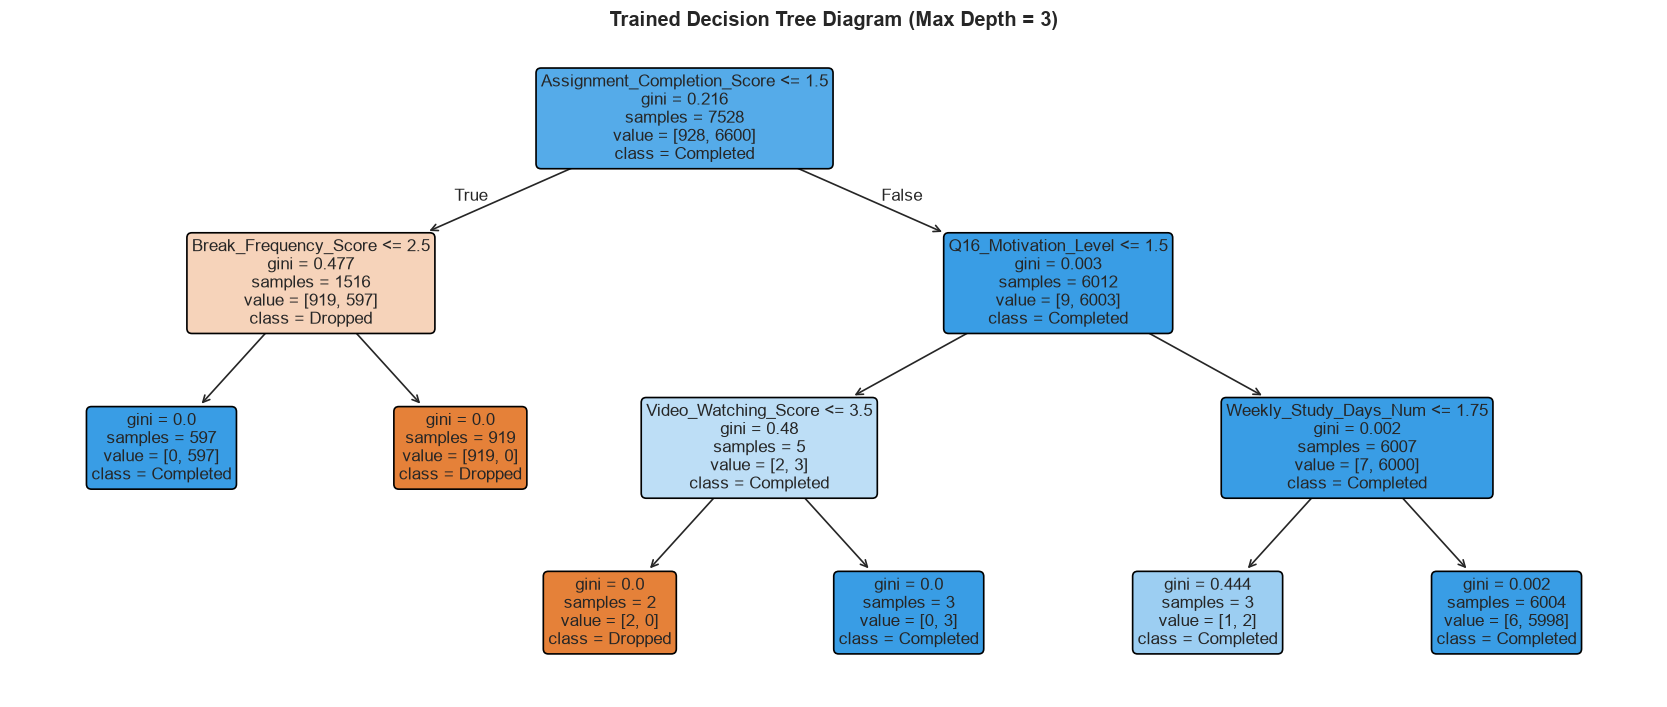

In [9]:
# Print Decision Tree Rules
tree_rules = export_text(dt_model, feature_names=feature_cols)
print("=== Decision Tree Rules ===")
print(tree_rules)

# Plot Decision Tree
plt.figure(figsize=(14, 6))
plot_tree(dt_model, feature_names=feature_cols, class_names=['Dropped', 'Completed'], filled=True, rounded=True, fontsize=10)
plt.title('Trained Decision Tree Diagram (Max Depth = 3)', fontweight='bold')
plt.tight_layout()
plt.show()

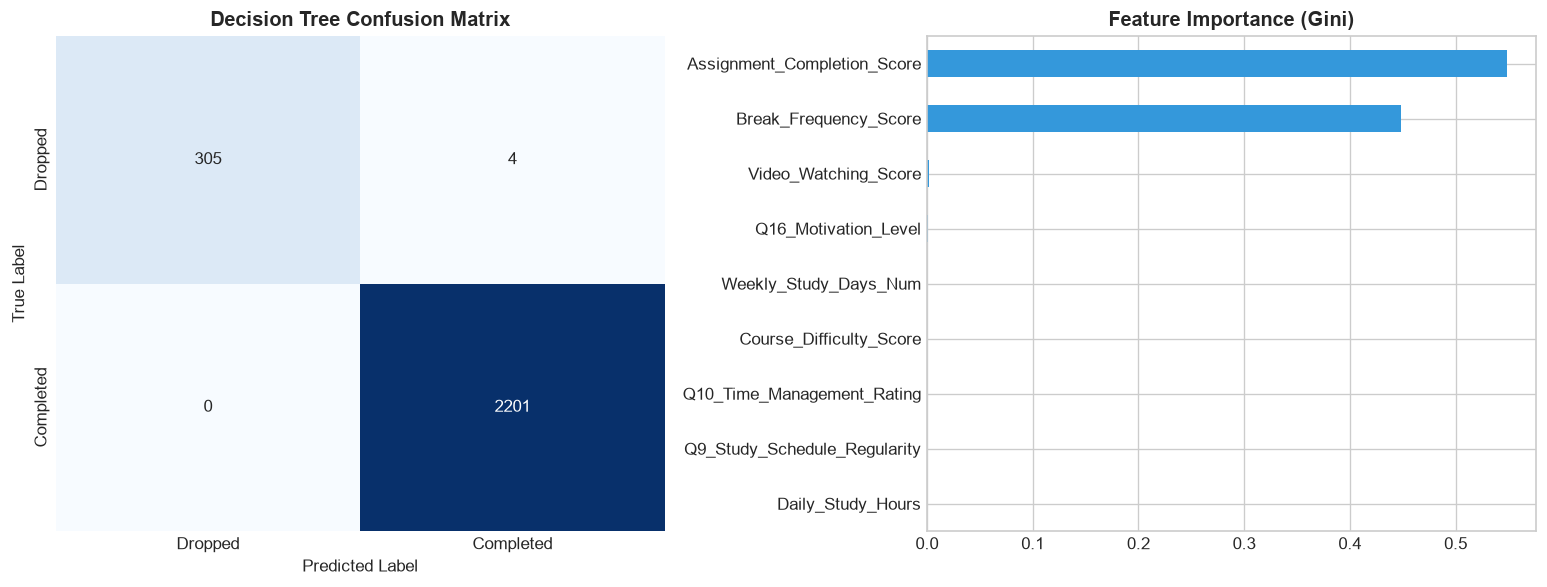

In [10]:
# Confusion Matrix & Feature Importances
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, dt_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Dropped', 'Completed'], yticklabels=['Dropped', 'Completed'], ax=ax[0])
ax[0].set_title('Decision Tree Confusion Matrix', fontweight='bold')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

importances = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind='barh', color='#3498db', ax=ax[1])
ax[1].set_title('Feature Importance (Gini)', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# State-of-the-Art (SOTA) Comparison Table (Verified Citations)
sota_data = [
    {
        "Study": "Kuzilek et al. (2017)",
        "Dataset": "Open University Learning Analytics Dataset (OULAD) (N=32,593, 22 courses)",
        "Method": "OULAD Benchmark Dataset Description & Baseline Metrics",
        "Metric": "32,593 Students, 10.6M VLE Clicks",
        "Comparison": "OULAD documents raw server VLE clickstreams. Our work uses direct student behavioral survey responses & break rules."
    },
    {
        "Study": "Mubarak et al. (2020)",
        "Dataset": "MOOC Video Clickstream Data (N=15,000)",
        "Method": "LSTM Recurrent Neural Networks",
        "Metric": "Accuracy: 89%–95% (Weekly)",
        "Comparison": "LSTM captures sequential video clicks week-by-week. Our Decision Tree model provides explicit IF-THEN rules with zero opacity."
    },
    {
        "Study": "Waheed et al. (2020)",
        "Dataset": "VLE Big Data (OULAD Benchmark, N=32,593)",
        "Method": "Deep Artificial Neural Network (DNN)",
        "Metric": "Accuracy: 84%–90% (Article 106189)",
        "Comparison": "Waheed et al. applied Deep Learning on clickstreams. Our Decision Tree emphasizes human-interpretable break frequency thresholds."
    }
]

df_sota = pd.DataFrame(sota_data)
print("=== State-of-the-Art (SOTA) Comparison Table ===")
df_sota

=== State-of-the-Art (SOTA) Comparison Table ===


,Study,Dataset,Method,Metric,Comparison
0,Kuzilek et al. (2017),Open University Learning Analytics Dataset (OU...,OULAD Benchmark Dataset Description & Baseline...,"32,593 Students, 10.6M VLE Clicks",OULAD documents raw server VLE clickstreams. O...
1,Mubarak et al. (2020),"MOOC Video Clickstream Data (N=15,000)",LSTM Recurrent Neural Networks,Accuracy: 89%–95% (Weekly),LSTM captures sequential video clicks week-by-...
2,Waheed et al. (2020),"VLE Big Data (OULAD Benchmark, N=32,593)",Deep Artificial Neural Network (DNN),Accuracy: 84%–90% (Article 106189),Waheed et al. applied Deep Learning on clickst...
